# Codigo para procesar datos de Arbin al igual con los de Bview

In [4]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path
from importlib import reload

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


## pruebo primero una función sola

(Al final no la uso porque es muy lenta)

In [2]:
from pathlib import Path
import pandas as pd
import re

file_in = Path("../data/JD_NMC04_015mA.xls")

# Obtener nombres de hoja
xls = pd.ExcelFile(file_in)
sheet_names = xls.sheet_names

# Filtrar hojas que empiecen con 'Global' o 'Statistics'
filtered_sheets = [s for s in sheet_names if not (s.startswith('Global') or s.startswith('Statistics'))]

print("Hojas en el archivo (original):", sheet_names)
print("Hojas filtradas (sin 'Global' ni 'Statistics'):", filtered_sheets)

# Reasignar si quieres usar la lista filtrada más adelante
sheet_names = filtered_sheets

# ahora puedes usar `sheet_names` para leer solo las hojas relevantes


Hojas en el archivo (original): ['Global_Info', 'Channel_1-006_1', 'Channel_1-006_2', 'Channel_1-006_3', 'Channel_1-006_4', 'Channel_1-006_5', 'Channel_1-006_6', 'Statistics_1-006']
Hojas filtradas (sin 'Global' ni 'Statistics'): ['Channel_1-006_1', 'Channel_1-006_2', 'Channel_1-006_3', 'Channel_1-006_4', 'Channel_1-006_5', 'Channel_1-006_6']


In [3]:
def carga_y_procesa_datos_arbin(file_in):
    """
    Carga y procesa un Excel Arbin para devolver:
      - dict_ciclos = {ciclo: df_ciclo}
      - dict_ciclos_sep = {ciclo: {'Ch': df_ciclo_ch, 'Dis': df_ciclo_dis}}
      - indices_ciclos = lista de ciclos encontrados

    Input:
    - file_in: ruta al archivo Excel de Arbin
    """
    file_in = Path(file_in)

    columnas = {
        'col_step_time':  'Step_Time(s)',
        'col_cycle_index':'Cycle_Index',
        'col_current':    'Current(A)',
        'col_voltage':    'Voltage(V)',
        'col_qch':        'Charge_Capacity(Ah)',
        'col_qdis':       'Discharge_Capacity(Ah)'
    }
    
    # --- Leer y concatenar hojas Channel ---
    df_all = pd.DataFrame()
    xls = pd.ExcelFile(file_in)
    sheet_names = xls.sheet_names
    print("Hojas en el archivo:", sheet_names)

    filtered_sheets = [
        s for s in sheet_names
        if not (s.startswith('Global') or s.startswith('Statistics'))
    ]

    for hoja in filtered_sheets:
        print(f"Leyendo hoja: {hoja}")
        try:
            df_hoja = pd.read_excel(
                file_in, 
                sheet_name=hoja,
                usecols=lambda c: c in columnas.values()
            )
            df_all = pd.concat([df_all, df_hoja], ignore_index=True)
        except Exception as e:
            print(f"Advertencia: no se pudo leer hoja {hoja}: {e}")
    
    if df_all.empty:
        raise ValueError("No se pudo leer ninguna hoja válida del archivo Arbin.")

    # --- Procesar ciclos ---
    dict_ciclos = {}
    dict_ciclos_sep = {}

    for ciclo, grupo in df_all.groupby(columnas['col_cycle_index']):
        
        print(f"Procesando ciclo: {ciclo}")
        df_ciclo = grupo.copy().reset_index(drop=True)
        dict_ciclos[ciclo] = df_ciclo

        # Separación carga / descarga
        df_ch = df_ciclo[df_ciclo[columnas['col_current']] > 0].copy()
        df_dis = df_ciclo[df_ciclo[columnas['col_current']] < 0].copy()

        # Si tiene Step_Time(s), calcular Time y Q
        if 'Step_Time(s)' in df_ciclo.columns:
            for df_tmp in (df_ch, df_dis):
                df_tmp['Time'] = df_tmp['Step_Time(s)'].cumsum() / 3600
                df_tmp['Current_mA'] = df_tmp[columnas['col_current']] * 1000
                df_tmp['Q'] = df_tmp['Time'] * abs(df_tmp['Current_mA'])
                df_tmp.reset_index(drop=True, inplace=True)

        dict_ciclos_sep[ciclo] = {'Ch': df_ch, 'Dis': df_dis}

        indices_ciclos = sorted(dict_ciclos.keys())

    return dict_ciclos, dict_ciclos_sep, indices_ciclos

In [4]:
file_in = Path("../data/JD_NMC04_015mA.xls")

dict_ciclos, dict_ciclos_sep, indices_ciclos = carga_y_procesa_datos_arbin(file_in)

Hojas en el archivo: ['Global_Info', 'Channel_1-006_1', 'Channel_1-006_2', 'Channel_1-006_3', 'Channel_1-006_4', 'Channel_1-006_5', 'Channel_1-006_6', 'Statistics_1-006']
Leyendo hoja: Channel_1-006_1
Leyendo hoja: Channel_1-006_2
Leyendo hoja: Channel_1-006_2
Leyendo hoja: Channel_1-006_3
Leyendo hoja: Channel_1-006_3
Leyendo hoja: Channel_1-006_4
Leyendo hoja: Channel_1-006_4
Leyendo hoja: Channel_1-006_5
Leyendo hoja: Channel_1-006_5
Leyendo hoja: Channel_1-006_6
Leyendo hoja: Channel_1-006_6
Procesando ciclo: 1
Procesando ciclo: 2
Procesando ciclo: 3
Procesando ciclo: 4
Procesando ciclo: 5
Procesando ciclo: 6
Procesando ciclo: 7
Procesando ciclo: 8
Procesando ciclo: 9
Procesando ciclo: 10
Procesando ciclo: 11
Procesando ciclo: 12
Procesando ciclo: 13
Procesando ciclo: 14
Procesando ciclo: 15
Procesando ciclo: 16
Procesando ciclo: 1
Procesando ciclo: 2
Procesando ciclo: 3
Procesando ciclo: 4
Procesando ciclo: 5
Procesando ciclo: 6
Procesando ciclo: 7
Procesando ciclo: 8
Procesando c

In [10]:
dict_ciclos_sep[10]['Ch'].head()


,Step_Time(s),Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Time,Current_mA,Q
0,10.000866,10,0.00015,2.750593,4.173695e-07,0.004259,0.002778,0.150276,0.000417
1,20.009272,10,0.00015,2.875542,8.350676e-07,0.004259,0.008336,0.150241,0.001252
2,30.012717,10,0.00015,2.971632,1.252561e-06,0.004259,0.016673,0.150241,0.002505
3,40.022159,10,0.00015,3.049917,1.670303e-06,0.004259,0.027790,0.150241,0.004175
4,50.026638,10,0.00015,3.116535,2.087843e-06,0.004259,0.041687,0.150311,0.006266


In [5]:
pl.plot_n_cycles_tvsV(indices_ciclos, dict_ciclos_sep, nombre_grafico='plot', scatter=False)

NameError: name 'indices_ciclos' is not defined

# Paso primero a csv para mayor velocidad

In [6]:
import pandas as pd
from pathlib import Path

In [28]:
def arbin_excel_a_csv(file_in, carpeta_out):
    """
    Convierte todas las hojas Channel del Excel Arbin a CSV.
    Se saltean hojas Global y Statistics.
    """
    file_in = Path(file_in)
    carpeta_out = Path(carpeta_out)
    carpeta_out.mkdir(exist_ok=True, parents=True)

    xls = pd.ExcelFile(file_in)

    for sheet in xls.sheet_names:
        if sheet.startswith("Global") or sheet.startswith("Statistics"):
            continue

        df = pd.read_excel(file_in, sheet_name=sheet)
        df.to_csv(carpeta_out / f"{sheet}.csv", index=False)
        print(f"Guardado: {carpeta_out / f'{sheet}.csv'}")

    print("Conversión a CSV terminada.")

In [29]:
def cargar_csv_arbin(carpeta_csv):
    """
    Carga todos los CSV generados desde un Excel Arbin.
    Devuelve un único DataFrame concatenado.
    """
    carpeta_csv = Path(carpeta_csv)
    archivos = sorted(carpeta_csv.glob("*.csv"))

    if not archivos:
        raise ValueError("No se encontraron CSV en la carpeta.")

    dfs = [pd.read_csv(f) for f in archivos]
    df_all = pd.concat(dfs, ignore_index=True)

    return df_all

In [41]:
def procesar_arbin(df_all):
    """
    Recibe el df_all ya cargado desde CSV.
    Devuelve:
      - dict_ciclos
      - dict_ciclos_sep
      - indices_ciclos
    """

    columnas = {
        'time': 'Test_Time(s)',
        'cycle': 'Cycle_Index',
        'current': 'Current(A)',
        'step_time': 'Step_Time(s)',
        'voltage': 'Voltage(V)',
    }

    dict_ciclos = {}
    dict_ciclos_sep = {}

    for ciclo, grupo in df_all.groupby(columnas['cycle']):
        df_ciclo = grupo.copy().reset_index(drop=True)
        dict_ciclos[ciclo] = df_ciclo

        # Carga y descarga
        df_ch  = df_ciclo[df_ciclo[columnas['current']] > 0].copy()
        df_dis = df_ciclo[df_ciclo[columnas['current']] < 0].copy()

        # Tiempo relativo tipo BView
        df_ch['Time']  = df_ch[columnas['step_time']].cumsum() / 3600
        df_dis['Time'] = df_dis[columnas['step_time']].cumsum() / 3600

        # Corriente en mA
        df_ch['Current_mA']  = df_ch[columnas['current']] * 1000
        df_dis['Current_mA'] = df_dis[columnas['current']] * 1000

        # Capacidad equivalente Q = I[mA] * t[h]
        df_ch['Q']  = df_ch['Time'] * abs(df_ch['Current_mA'])
        df_dis['Q'] = df_dis['Time'] * abs(df_dis['Current_mA'])


        # === NUEVO: renombrar columnas estilo BView ===
        df_ch['Current'] = df_ch[columnas['current']]
        df_dis['Current'] = df_dis[columnas['current']]

        df_ch['CellV'] = df_ch[columnas['voltage']]
        df_dis['CellV'] = df_dis[columnas['voltage']]

        # Dejar SOLO las 4 columnas finales estilo BView
        df_ch = df_ch[['Time', 'Current', 'CellV', 'Q']]
        df_dis = df_dis[['Time', 'Current', 'CellV', 'Q']]
        # ===============================================


        df_ch.reset_index(drop=True, inplace=True)
        df_dis.reset_index(drop=True, inplace=True)

        dict_ciclos_sep[ciclo] = {"Ch": df_ch, "Dis": df_dis}

    indices_ciclos = sorted(dict_ciclos.keys())
    return dict_ciclos, dict_ciclos_sep, indices_ciclos

In [11]:
# 1) Convertir Excel a CSV (una sola vez)
arbin_excel_a_csv("../data/JD_NMC04_015mA.xls", "../tmp/arbin_csv_nmc04")


Conversión a CSV terminada.


In [49]:
# 2) Cargar todos los CSV (rápido)
df_all = cargar_csv_arbin("../tmp/arbin_csv_nmc04")

df_all.head()

,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,60.009626,2025-07-08 16:58:33,60.009626,1,1,0.0,3.636284,0.0,1.490570e-10,0.0,5.419680e-10,0.002896,0,0,0,0
1,2,120.013318,2025-07-08 16:59:33,120.013318,1,1,0.0,3.635977,0.0,1.490570e-10,0.0,5.419680e-10,0.000000,0,0,0,0
2,3,180.015078,2025-07-08 17:00:33,180.015079,1,1,0.0,3.636284,0.0,1.490570e-10,0.0,5.419680e-10,0.000000,0,0,0,0
3,4,240.023577,2025-07-08 17:01:33,240.023577,1,1,0.0,3.636284,0.0,1.490570e-10,0.0,5.419680e-10,0.000000,0,0,0,0
4,5,300.033367,2025-07-08 17:02:33,300.033367,1,1,0.0,3.636284,0.0,1.490570e-10,0.0,5.419680e-10,0.000000,0,0,0,0


In [54]:
# 3) Procesar
dict_ciclos, dict_ciclos_sep, indices = procesar_arbin(df_all)

In [51]:
dict_ciclos_sep[10]['Ch'].head()


,Time,Current,CellV,Q
0,0.002778,0.00015,2.750593,0.000417
1,0.008336,0.00015,2.875542,0.001252
2,0.016673,0.00015,2.971632,0.002505
3,0.027790,0.00015,3.049917,0.004175
4,0.041687,0.00015,3.116535,0.006266


In [52]:
reload(pl)

<module 'plotting' from '/home/mariajose/proc-icdv/src/plotting.py'>

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


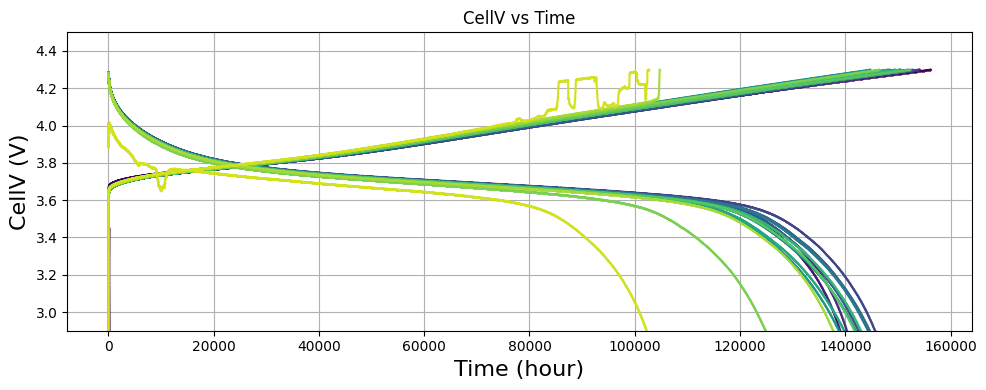

In [53]:
pl.plot_n_cycles_tvsV(indices[0:15], dict_ciclos_sep, nombre_grafico='plot', scatter=False)

In [55]:
output_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = 'arbin-NMC04'
pr.crear_json(dict_ciclos_sep, output_folder / f"{nombre_archivo}.json")

Archivo JSON creado en: /home/mariajose/proc-icdv/tmp/arbin-NMC04.json
